<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/50DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

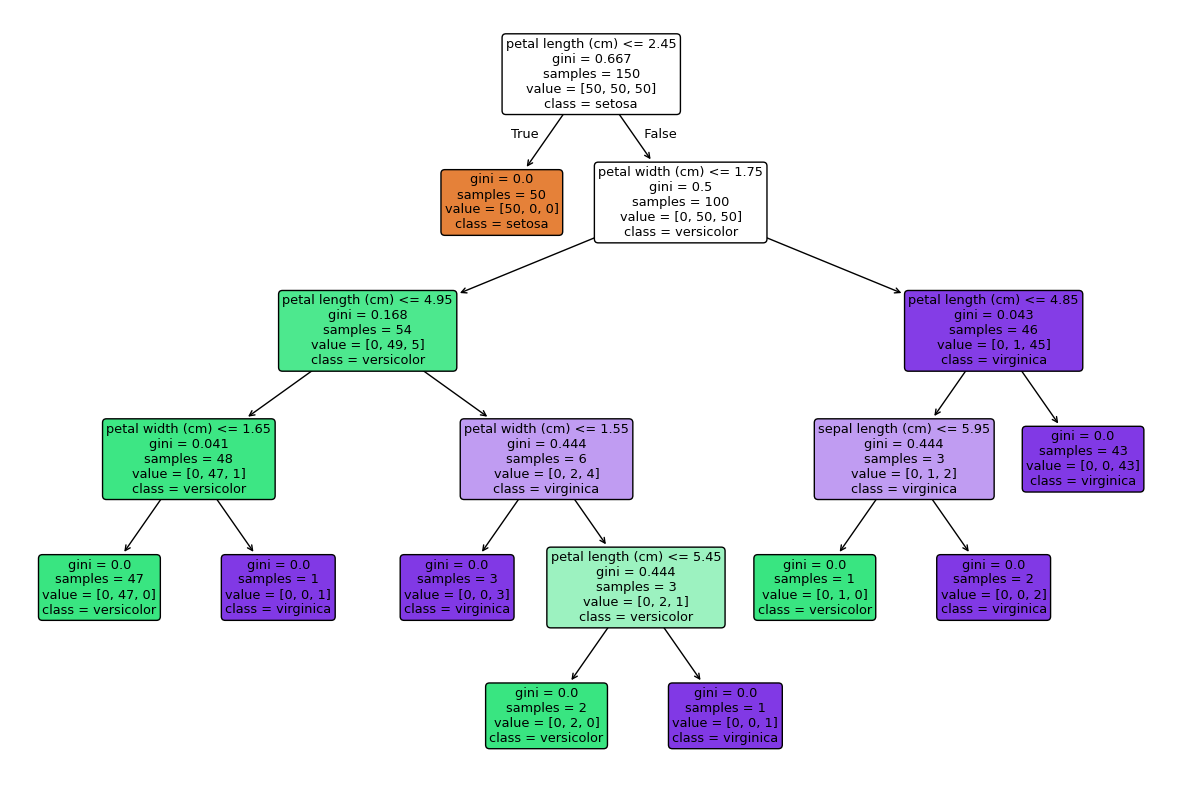

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ডেটাসেট লোড করা
iris = load_iris()
X, y = iris.data, iris.target

# ১. Decision Tree মডেল তৈরি (ডিফল্ট প্যারামিটার দিয়ে)
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X, y)

# ২. Visualization বা ট্রি চিত্রায়িত করা
plt.figure(figsize=(15, 10))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
)
plt.show()

Max Depth পরিবর্তন করলে কী হয়?max_depth হলো একটি হাইপারপ্যারামিটার (Hyperparameter) যা ডিসিশন ট্রির সর্বোচ্চ গভীরতা বা লেভেল নিয়ন্ত্রণ করে। এটি পরিবর্তন করলে যা ঘটে:

কম Depth (যেমন max_depth=1 বা 2): ট্রি খুব ছোট বা সাধারণ হয়। মডেলটি ডেটার জটিলতা বুঝতে পারে না, যাকে Underfitting বলে।

বেশি বা আনলিমিটেড Depth (Default): ট্রি অনেক গভীর হয় এবং ট্রেনিং ডেটার একেবারে শেষ বিন্দু পর্যন্ত নিখুঁতভাবে শেখার চেষ্টা করে। এর ফলে মডেল ট্রেনিং ডেটাতে ১০০% সঠিক হলেও নতুন ডেটাতে ভুল করে, যাকে Overfitting বলে।

সঠিক Depth নির্বাচন: এটি মডেলকে অতিরিক্ত জটিল হওয়া থেকে বাঁচায় (Pruning) এবং জেনারেলাইজেশন ক্ষমতা বাড়ায়।

In [2]:
# ফিচার ইম্পর্ট্যান্স প্রিন্ট করা
for name, importance in zip(iris.feature_names, clf.feature_importances_):
    print(f"{name}: {importance:.4f}")

sepal length (cm): 0.0133
sepal width (cm): 0.0000
petal length (cm): 0.5641
petal width (cm): 0.4226


In [3]:
# 1. Get the index of the feature used at the root node (node 0)
root_feature_index = clf.tree_.feature[0]

# 2. Map it to the feature name
root_feature_name = iris.feature_names[root_feature_index]

print(f"The Root Node Feature is: {root_feature_name}")

The Root Node Feature is: petal length (cm)


Feature Importance: ডেটা স্প্লিট করার কারণে স্কোরের সামান্য পরিবর্তন হতে পারে, তবে依旧 petal length (cm) বা petal width (cm) সবচেয়ে বেশি গুরুত্বপূর্ণ ফিচার হিসেবে থাকবে।

Root Node: চিত্রটি লক্ষ করলে দেখতে পাবেন, এবারও petal length (cm) (বা কিছু ক্ষেত্রে petal width (cm)) রুট নোড হিসেবে এসেছে, কারণ এটি ট্রেনিং সেটের Setosa ক্লাসটিকে এক ক্লিকেই পুরোপুরি আলাদা করতে পারে।কো

Training Accuracy: 98.33%
Testing Accuracy: 96.67%

--- Feature Importances ---
sepal length (cm): 0.0000
sepal width (cm): 0.0000
petal length (cm): 0.5791
petal width (cm): 0.4209


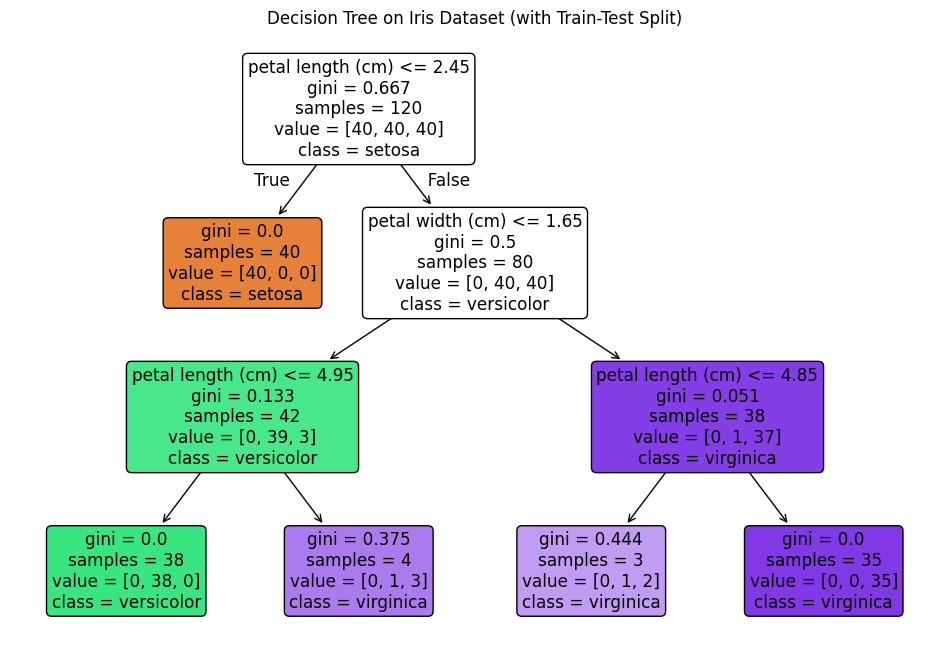

In [4]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ডেটাসেট লোড করা
iris = load_iris()
X, y = iris.data, iris.target

# ৮-২০ অনুপাতে Train এবং Test সেটে ডেটা বিভক্ত করা (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ১. Decision Tree মডেল তৈরি এবং ট্রেইনিং
# (max_depth=3 দিয়ে ওভারফিটিং নিয়ন্ত্রণ করা হয়েছে)
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# মডেলের নির্ভুলতা (Accuracy) পরীক্ষা
train_acc = clf.score(X_train, y_train)
test_acc = clf.score(X_test, y_test)
print(f"Training Accuracy: {train_acc:.2%}")
print(f"Testing Accuracy: {test_acc:.2%}\n")

# ৪. Feature Importance বের করা
print("--- Feature Importances ---")
for name, importance in zip(iris.feature_names, clf.feature_importances_):
    print(f"{name}: {importance:.4f}")

# ২. Visualization বা ট্রি চিত্রায়িত করা
plt.figure(figsize=(12, 8))
plot_tree(
    clf,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
)
plt.title("Decision Tree on Iris Dataset (with Train-Test Split)")
plt.show()

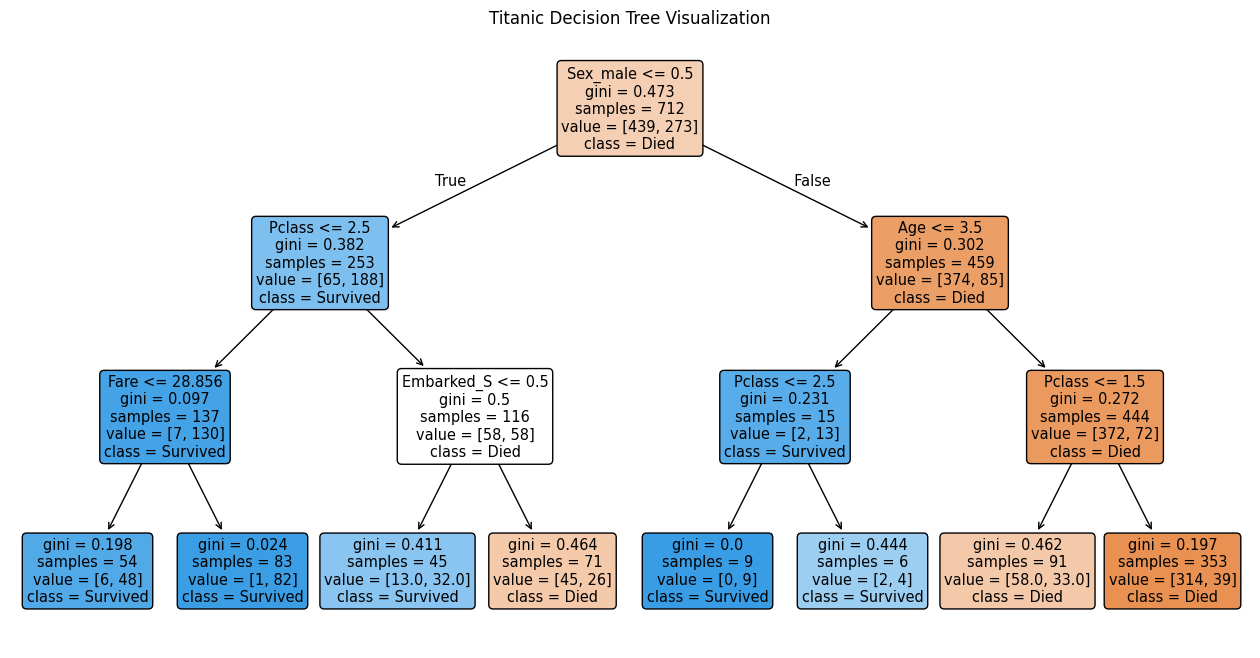

Testing Accuracy: 77.65%

--- Confusion Matrix ---
[[101   9]
 [ 31  38]]


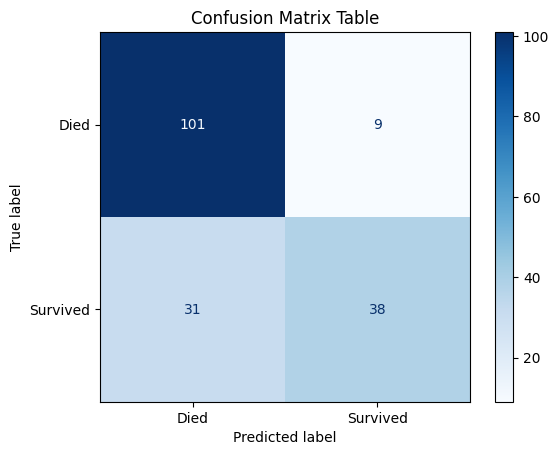


--- Feature Importances ---
Pclass: 0.2229
Age: 0.0909
Fare: 0.0041
Sex_male: 0.6408
Embarked_Q: 0.0000
Embarked_S: 0.0414


In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ডেটা লোড করা
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# নির্দিষ্ট ফিচার এবং টার্গেট আলাদা করা
features = ["Pclass", "Sex", "Age", "Fare", "Embarked"]
X = df[features].copy()
y = df["Survived"]

# ----------------------------------------------------
# ২. Missing Values Handle করা
# ----------------------------------------------------
# 'Age' এবং 'Fare' এর মিসিং ভ্যালু Median দিয়ে পূরণ করা
X["Age"] = X["Age"].fillna(X["Age"].median())
X["Fare"] = X["Fare"].fillna(X["Fare"].median())

# 'Embarked' এর মিসিং ভ্যালু Mode (সবচেয়ে বেশি বার আসা মান) দিয়ে পূরণ করা
X["Embarked"] = X["Embarked"].fillna(X["Embarked"].mode()[0])

# ক্যাটাগরিক্যাল ডেটাকে সংখ্যায় রূপান্তর (One-Hot Encoding)
X = pd.get_dummies(X, columns=["Sex", "Embarked"], drop_first=True)

# ----------------------------------------------------
# ৩. Train-Test Split করা (80% Train, 20% Test)
# ----------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------------------------------
# ৪. Decision Tree Train করা
# ----------------------------------------------------
# ওভারফিটিং এড়াতে max_depth=3 ব্যবহার করা হয়েছে
clf = DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# ----------------------------------------------------
# ৫. Tree Visualize করা
# ----------------------------------------------------
plt.figure(figsize=(16, 8))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["Died", "Survived"],
    filled=True,
    rounded=True,
)
plt.title("Titanic Decision Tree Visualization")
plt.show()

# ----------------------------------------------------
# ৬. Accuracy বের করা
# ----------------------------------------------------
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Testing Accuracy: {accuracy:.2%}\n")

# ----------------------------------------------------
# ৭. Confusion Matrix বের করা
# ----------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
print("--- Confusion Matrix ---")
print(cm)

# Confusion Matrix সুন্দরভাবে প্রদর্শন
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Died", "Survived"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix Table")
plt.show()

# ----------------------------------------------------
# ৮. কোন Feature সবচেয়ে গুরুত্বপূর্ণ?
# ----------------------------------------------------
print("\n--- Feature Importances ---")
for name, importance in zip(X.columns, clf.feature_importances_):
    print(f"{name}: {importance:.4f}")

In [6]:
# 1. Get the index of the feature used at the root node (node 0)
root_feature_index = clf.tree_.feature[0]

# 2. Map it to the feature name
root_feature_name = X.columns[root_feature_index]

print(f"The Root Node Feature is: {root_feature_name}")

The Root Node Feature is: Sex_male
